<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/20_08_26_Multi_Class_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multi-Class Classification: CIFAR-10 Object Classifier

This notebook aims to build and train a multi-class classification model using the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

First, we will load and explore the dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Display basic information about the dataset
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Number of training samples: {len(x_train)}")
print(f"Number of test samples: {len(x_test)}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2026s 12us/step
Shape of x_train: (50000, 32, 32, 3)
Shape of y_train: (50000, 1)
Shape of x_test: (10000, 32, 32, 3)
Shape of y_test: (10000, 1)
Number of training samples: 50000
Number of test samples: 10000


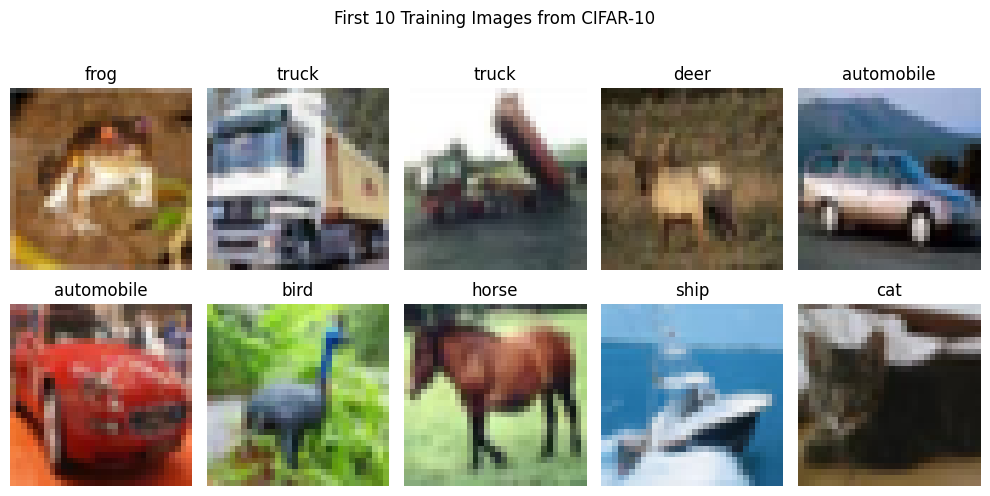

In [ ]:
# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Display the first 10 training images with their labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('First 10 Training Images from CIFAR-10', y=1.02) # Add a main title
plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"Shape of x_train_normalized: {x_train_normalized.shape}")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of x_test_normalized: {x_test_normalized.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")


Shape of x_train_normalized: (50000, 32, 32, 3)
Shape of y_train_one_hot: (50000, 10)
Shape of x_test_normalized: (10000, 32, 32, 3)
Shape of y_test_one_hot: (10000, 10)


In [ ]:
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(x_train_normalized, y_train_one_hot,
                    epochs=10,
                    batch_size=64,
                    validation_data=(x_test_normalized, y_test_one_hot))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7702 - loss: 0.6558 - val_accuracy: 0.7085 - val_loss: 0.8622
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7792 - loss: 0.6272 - val_accuracy: 0.7125 - val_loss: 0.8541
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7901 - loss: 0.6004 - val_accuracy: 0.7128 - val_loss: 0.8645
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7964 - loss: 0.5781 - val_accuracy: 0.7134 - val_loss: 0.8631
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.8083 - loss: 0.5451 - val_accuracy: 0.7111 - val_loss: 0.8866
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.8168 - loss: 0.5191 - val_accuracy: 0.7116 - val_loss: 0.8789
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.8266 - loss: 0.4925 - val_accuracy: 0.7176 - val_loss: 0.8802
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.8308 - loss: 0.4743 - 

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=2)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 - 4s - 13ms/step - accuracy: 0.7161 - loss: 0.9517
Test Loss: 0.9517
Test Accuracy: 0.7161


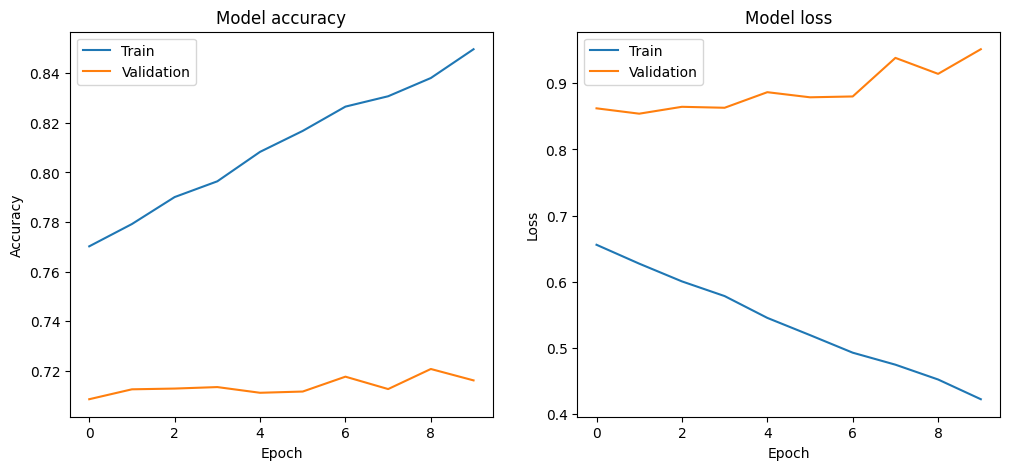

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Train the model
history = model.fit(x_train_normalized, y_train_one_hot,
                    epochs=10,
                    batch_size=64,
                    validation_data=(x_test_normalized, y_test_one_hot))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.4154 - loss: 1.5953 - val_accuracy: 0.5114 - val_loss: 1.3492
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.5617 - loss: 1.2307 - val_accuracy: 0.5824 - val_loss: 1.1562
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.6199 - loss: 1.0771 - val_accuracy: 0.6036 - val_loss: 1.1126
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6580 - loss: 0.9770 - val_accuracy: 0.6325 - val_loss: 1.0625
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.6824 - loss: 0.9086 - val_accuracy: 0.6899 - val_loss: 0.9042
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.7050 - loss: 0.8483 - val_accuracy: 0.6978 - val_loss: 0.8741
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.7202 - loss: 0.7997 - val_accuracy: 0.6876 - val_loss: 0.8962
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.7359 - loss: 0.7520 - 